In [53]:
from neuron import h, n
import matplotlib.pyplot as plt

Text(0, 0.5, 'Current from Clamp')

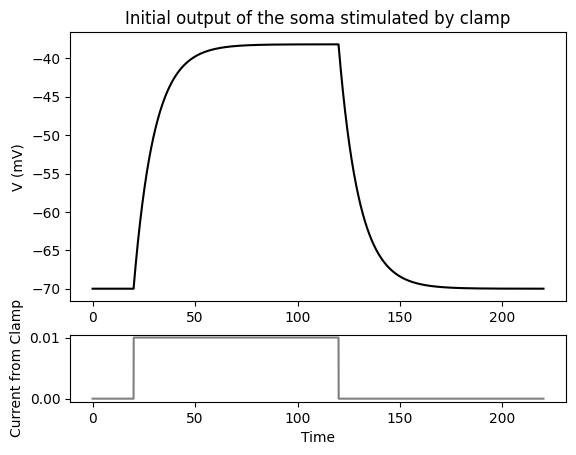

In [54]:

n.load_file('bilayer.hoc')


soma = h.Section(name='soma')
soma.L = 10 # length µm
soma.diam = 10 # diameter µm
soma.insert('pas')# add passive properties  
soma.g_pas = 1/10000 # set the specific membrane; resistance to 10000 ohm*cm^2

stim = h.IClamp(soma(0.5))
stim.delay = 20 # start of the current injection (ms)
stim.dur= 100 # duration (ms)
stim.amp= 0.01 # amplitude (nA)

# record voltage of some and injected current
# and the time
soma_v = h.Vector()
soma_v.record(soma(0.5)._ref_v)

stim_current = h.Vector()
stim_current.record(stim._ref_i)

t = h.Vector()
t.record(h._ref_t)

# run simulation
h.tstop = 220 # set the simulation time
h.dt = 0.025
h.v_init = -70
h.run()

# plotting
f, (ax0, ax1) = plt.subplots(2,1, gridspec_kw = {'height_ratios':[4, 1]})
ax0.plot(t,soma_v, 'k') #x,y 
ax0.set_ylabel('V (mV)')
ax0.set_title('Initial output of the soma stimulated by clamp')


ax1.plot(t,stim_current, 'gray', label='I (nA)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Current from Clamp')



Now that there's a soma. It's dendrite time. 

In [55]:
dend = h.Section(name="dend")
dend.L = 500 # um
dend.diam = 1# um
dend.Ra= 100 # ohm*cm
dend.insert('pas')
dend.g_pas = 1/10000
dend.connect(soma, 1, 0) #connect the end of the soma
			   #to the start of the dendrite

h("forall { nseg = int((L/(0.1*lambda_f(100))+0.9)/2)*2 + 1 }")  # set the number
					#of segments


True

In [56]:
stim = h.IClamp(soma(0.5)) # add a current clamp the 			    # the middle of the soma
stim.delay = 10  # ms
stim.dur = 100
stim.amp = 0.1 # nA
soma_v = h.Vector() # set up a recording vector
soma_v.record(soma(0.5)._ref_v)# record voltage at the 				#middle of the soma
# Record voltage from all segments in the dendrite
dend_vs = []
for seg in dend:
    dend_vs.append(h.Vector())
    dend_vs[-1].record(seg._ref_v)

t = h.Vector()
t.record(h._ref_t) #record time.
h.v_init = -70 # set starting voltage 
h.tstop = 200 # set simulation time
h.run() # run simulation


0.0

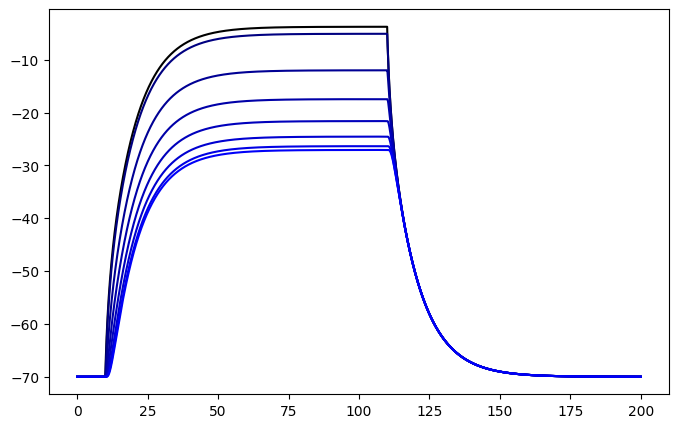

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(t, soma_v,color='k',label='soma(0.5)')
for i,v in list(enumerate(dend_vs))[::3]:
    plt.plot(t, v, color=(0,0,0.5+0.5*i/len(dend_vs)), label = 'dend({:.2})'.format(i/len(dend_vs)))

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Voltage after adding dendrite')

In [58]:
#hudgkin huxley time yayayayayasy

h.tstop = 25
stim.dur = 5

soma.insert('hh') # add Hodgkin-Huxley channels

h.celsius = 30
